In [9]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("Cleaned_dataset.csv")

In [3]:
data.head()

,Gender,Senior Citizen,Dependents,Tenure,Phone Service,Multiple Lines,Internet Service,Contract,Monthly Charges,Churn,Tenure_group,Charges_per_tenure
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes,New,12.500000
1,Male,0,No,41,Yes,No,DSL,One year,25,No,Medium,0.595238
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No,Loyal,0.358491
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes,New,38.000000
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No,Loyal,0.750000


In [ ]:
pip install scikit-learn

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [11]:
X_train = np.load("X_train.npy")
X_test = np.load("X_test.npy")

y_train = pd.read_csv("y_train.csv")
y_test = pd.read_csv("y_test.csv")

In [12]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

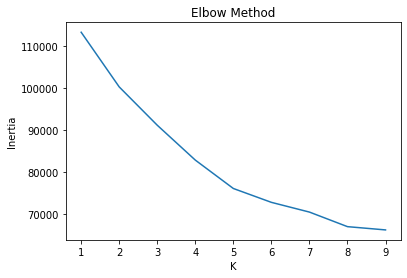

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("K")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)

train_clusters = kmeans.fit_predict(X_train_scaled)
test_clusters = kmeans.predict(X_test_scaled)

In [22]:
df_cluster = pd.DataFrame(X_train)
df_cluster['Cluster'] = train_clusters
df_cluster['Churn'] = y_train.values.ravel()

In [23]:
y_train.shape

(5392, 1)

In [25]:
df_cluster['Churn'] = df_cluster['Churn'].map({'Yes': 1, 'No': 0})

In [26]:
cluster_analysis = df_cluster.groupby('Cluster')['Churn'].mean()
print(cluster_analysis)

Cluster
0    0.248649
1    0.390997
2    0.113541
Name: Churn, dtype: float64


In [27]:
print(df_cluster['Churn'].unique())

[0 1]


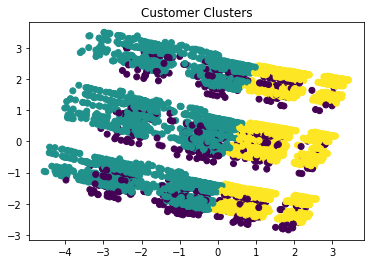

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=train_clusters)
plt.title("Customer Clusters")
plt.show()